✅ Library berhasil diimport
📂 Siapkan folder dataset Anda di Google Drive atau upload manual


100%|██████████| 40/40 [00:05<00:00,  7.33it/s]


✅ Dataset berhasil dimuat: 120 gambar
Training: 96 | Testing: 24
Best Parameter: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

🎯 Akurasi Model: 91.67%

Classification Report:
              precision    recall  f1-score   support

        Baik       0.88      0.88      0.88         8
      Sedang       0.88      0.88      0.88         8
       Buruk       1.00      1.00      1.00         8

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24



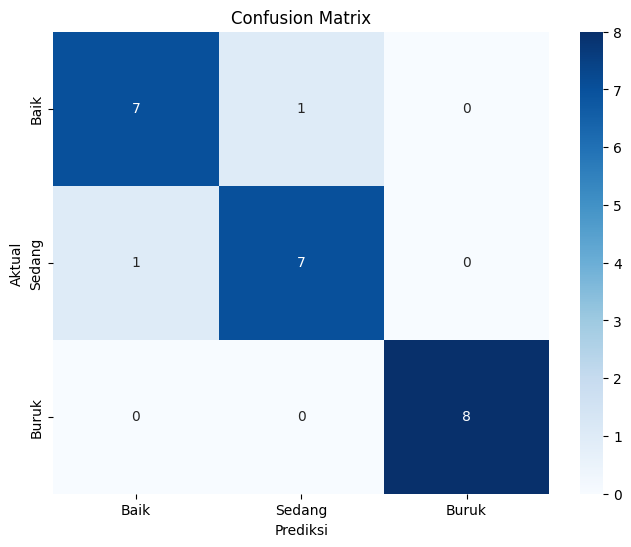

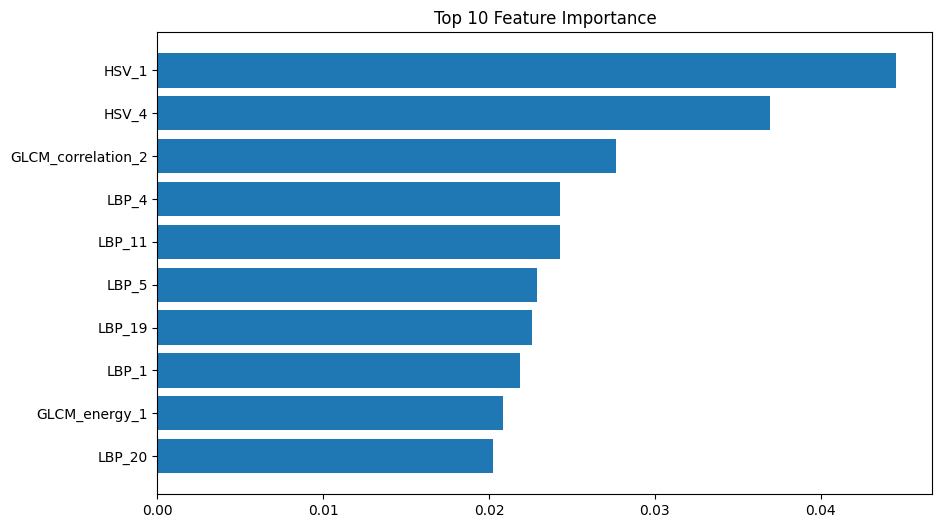

💾 Model berhasil disimpan sebagai 'random_forest_tempe_model.pkl'


In [5]:
# =====================================================
# DETEKSI KUALITAS TEMPE BERBASIS CITRA TEKSTUR & WARNA
# MENGGUNAKAN ALGORITMA RANDOM FOREST
# Skripsi - Sandik Bayu Asmoro (221101057)
# =====================================================

# --------------------- INSTALL LIBRARY ---------------------
!pip install -q opencv-python scikit-learn matplotlib seaborn pandas numpy joblib

# --------------------- IMPORT LIBRARY ---------------------
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
from skimage.feature import graycomatrix, graycoprops
import os
from tqdm import tqdm
from sklearn.model_selection import GridSearchCV
import warnings
from skimage.feature import local_binary_pattern
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport")

# ====================== 1. FUNGSI EKSTRAKSI FITUR ======================

def extract_color_features(image):

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mean_rgb = np.mean(rgb, axis=(0,1))
    std_rgb = np.std(rgb, axis=(0,1))

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    mean_hsv = np.mean(hsv, axis=(0,1))
    std_hsv = np.std(hsv, axis=(0,1))

    hist_r = cv2.calcHist([rgb],[0],None,[16],[0,256]).flatten()
    hist_g = cv2.calcHist([rgb],[1],None,[16],[0,256]).flatten()
    hist_b = cv2.calcHist([rgb],[2],None,[16],[0,256]).flatten()

    hist_features = np.concatenate([hist_r,hist_g,hist_b])

    return np.concatenate([
        mean_rgb,
        std_rgb,
        mean_hsv,
        std_hsv,
        hist_features
    ])

def extract_glcm_features(gray_image):
    """Ekstrak fitur tekstur menggunakan GLCM"""
    glcm = graycomatrix(gray_image, distances=[1,2,3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)

    props = ['contrast', 'correlation', 'energy', 'homogeneity', 'dissimilarity']
    features = []

    for prop in props:
        features.extend(graycoprops(glcm, prop)[0])

    return np.array(features)

def extract_features(image_path):
    """Ekstrak semua fitur dari satu gambar"""
    img = cv2.imread(image_path)
    if img is None:
        return None

    # Preprocessing
    img = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3,3), 0)

    color_feat = extract_color_features(img)
    glcm_feat = extract_glcm_features(gray)

    def extract_lbp_features(gray):

        radius = 3
        n_points = 8 * radius

        lbp = local_binary_pattern(
            gray,
            n_points,
            radius,
            method='uniform'
        )

        hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, n_points + 3),
            range=(0, n_points + 2)
        )

        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)

        return hist

    lbp_feat = extract_lbp_features(gray)

    return np.concatenate([
        color_feat,
        glcm_feat,
        lbp_feat
    ])

# ====================== 2. LOAD DATASET (Contoh) ======================

print("📂 Siapkan folder dataset Anda di Google Drive atau upload manual")

# Contoh struktur folder:
# /content/dataset/
#    ├── baik/
#    ├── sedang/
#    └── buruk/

# Ganti path sesuai lokasi dataset Anda
dataset_path = "/content/drive/MyDrive/Colab Notebooks/dataset"

X = []
y = []

if os.path.exists(dataset_path):
    classes = {'baik': 0, 'sedang': 1, 'buruk': 2}
    for class_name, label in classes.items():
        class_path = os.path.join(dataset_path, class_name)
        if os.path.exists(class_path):
            for img_name in tqdm(os.listdir(class_path)):
                img_path = os.path.join(class_path, img_name)
                features = extract_features(img_path)
                if features is not None:
                    X.append(features)
                    y.append(label)
    print(f"✅ Dataset berhasil dimuat: {len(X)} gambar")
else:
    print("⚠️ Folder dataset belum ada. Silakan upload dataset Anda.")

# ====================== 3. TRAINING MODEL ======================

if len(X) > 0:
    X = np.array(X)
    y = np.array(y)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                        random_state=42, stratify=y)

    print(f"Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")

    # Train Random Forest
    param_grid = {
        'n_estimators':[200,300,500],
        'max_depth':[10,20,30,None],
        'min_samples_split':[2,5,10],
        'min_samples_leaf':[1,2,4]
    }

    grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    model = grid.best_estimator_

    print("Best Parameter:", grid.best_params_)

    # Evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n🎯 Akurasi Model: {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Baik', 'Sedang', 'Buruk']))

    # Confusion Matrix
    plt.figure(figsize=(8,6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Baik', 'Sedang', 'Buruk'],
                yticklabels=['Baik', 'Sedang', 'Buruk'])
    plt.title('Confusion Matrix')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()

    # Feature Importance
    # Dynamically determine the size of LBP features
    # The length of LBP features is (n_points + 2)
    # n_points = 8 * radius, where radius=3. So, 8*3 + 2 = 26.
    num_lbp_features = 26 # Based on current implementation of extract_lbp_features
    feature_names = [
        *[f"RGB_{i}" for i in range(6)],
        *[f"HSV_{i}" for i in range(6)],
        *[f"GLCM_{p}_{a}" for p in ['contrast','correlation','energy','homogeneity','dissimilarity'] for a in range(4)],
        *[f"LBP_{i}" for i in range(num_lbp_features)]
    ]

    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]

    plt.figure(figsize=(10,6))
    plt.barh(range(10), importances[indices], align='center')
    plt.yticks(range(10), [feature_names[i] for i in indices])
    plt.title('Top 10 Feature Importance')
    plt.show()

    # Simpan Model
    joblib.dump(model, 'random_forest_tempe_model.pkl')
    print("💾 Model berhasil disimpan sebagai 'random_forest_tempe_model.pkl'")

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# Upload file(s) from your computer to Google Colab
print("Please select the image file(s) to upload.")
uploaded = files.upload()

# Check if any files were uploaded
if not uploaded:
    print("⚠️ No files were uploaded.")
else:
    print("✅ File(s) uploaded successfully!")
    for filename in uploaded.keys():
        try:
            img = Image.open(filename)

            plt.figure(figsize=(6,6))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"Uploaded Image: {filename}")
            plt.show()

            print(f"Nama File: {filename}")
            print(f"Ukuran Gambar: {img.size}")
        except Exception as e:
            print(f"Error processing {filename}: {e}")

Please select the image file(s) to upload.


⚠️ No files were uploaded.


✅ Library berhasil diimport
📂 Siapkan folder dataset Anda di Google Drive atau upload manual


100%|██████████| 40/40 [00:05<00:00,  7.46it/s]


✅ Dataset berhasil dimuat: 120 gambar

🌳 Training Decision Tree...

🌳 Akurasi Decision Tree: 79.17%

Classification Report Decision Tree:
              precision    recall  f1-score   support

        Baik       0.67      0.75      0.71         8
      Sedang       0.78      0.88      0.82         8
       Buruk       1.00      0.75      0.86         8

    accuracy                           0.79        24
   macro avg       0.81      0.79      0.80        24
weighted avg       0.81      0.79      0.80        24



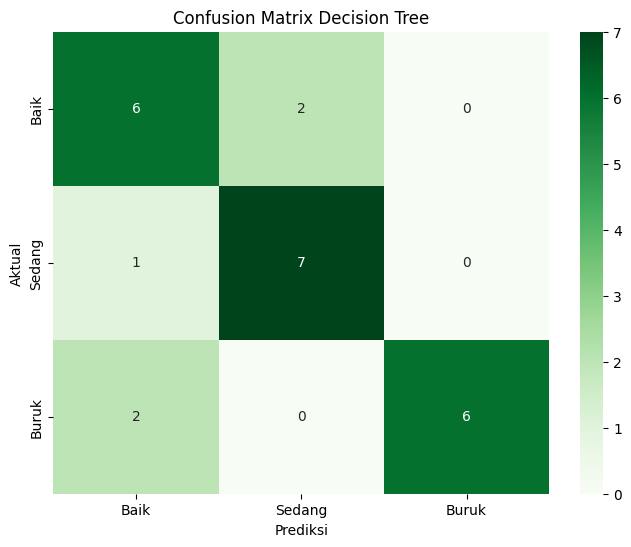

Training: 96 | Testing: 24
Best Parameter: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

🎯 Akurasi Model: 91.67%

Classification Report:
              precision    recall  f1-score   support

        Baik       0.88      0.88      0.88         8
      Sedang       0.88      0.88      0.88         8
       Buruk       1.00      1.00      1.00         8

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24



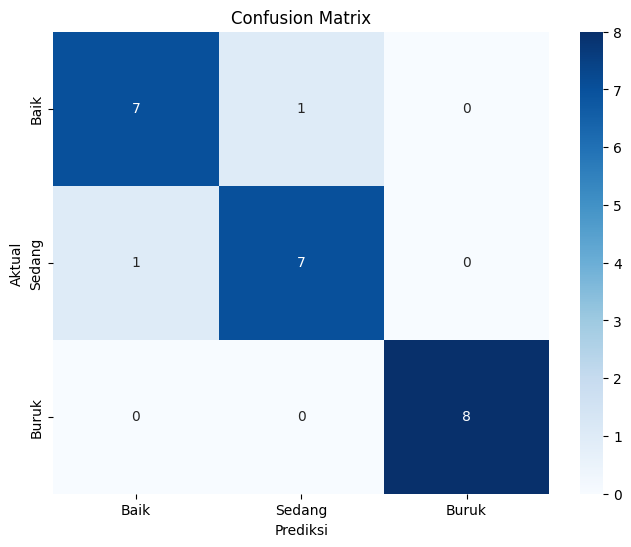

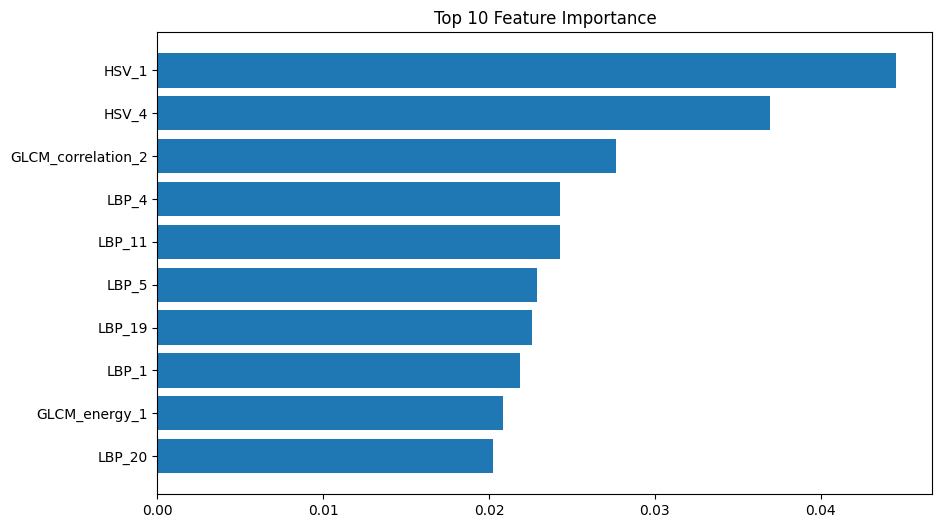

💾 Random Forest disimpan: random_forest_tempe_model.pkl
💾 Decision Tree disimpan: decision_tree_tempe_model.pkl


In [6]:
# =====================================================
# DETEKSI KUALITAS TEMPE BERBASIS CITRA TEKSTUR & WARNA
# MENGGUNAKAN ALGORITMA RANDOM FOREST
# Skripsi - Sandik Bayu Asmoro (221101057)
# =====================================================

# --------------------- INSTALL LIBRARY ---------------------
!pip install -q opencv-python scikit-learn matplotlib seaborn pandas numpy joblib

# --------------------- IMPORT LIBRARY ---------------------
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
from skimage.feature import graycomatrix, graycoprops
import os
from tqdm import tqdm
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
import warnings
from skimage.feature import local_binary_pattern
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport")

# ====================== 1. FUNGSI EKSTRAKSI FITUR ======================

def extract_color_features(image):

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mean_rgb = np.mean(rgb, axis=(0,1))
    std_rgb = np.std(rgb, axis=(0,1))

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    mean_hsv = np.mean(hsv, axis=(0,1))
    std_hsv = np.std(hsv, axis=(0,1))

    hist_r = cv2.calcHist([rgb],[0],None,[16],[0,256]).flatten()
    hist_g = cv2.calcHist([rgb],[1],None,[16],[0,256]).flatten()
    hist_b = cv2.calcHist([rgb],[2],None,[16],[0,256]).flatten()

    hist_features = np.concatenate([hist_r,hist_g,hist_b])

    return np.concatenate([
        mean_rgb,
        std_rgb,
        mean_hsv,
        std_hsv,
        hist_features
    ])

def extract_glcm_features(gray_image):
    """Ekstrak fitur tekstur menggunakan GLCM"""
    glcm = graycomatrix(gray_image, distances=[1,2,3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)

    props = ['contrast', 'correlation', 'energy', 'homogeneity', 'dissimilarity']
    features = []

    for prop in props:
        features.extend(graycoprops(glcm, prop)[0])

    return np.array(features)

def extract_features(image_path):
    """Ekstrak semua fitur dari satu gambar"""
    img = cv2.imread(image_path)
    if img is None:
        return None

    # Preprocessing
    img = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3,3), 0)

    color_feat = extract_color_features(img)
    glcm_feat = extract_glcm_features(gray)

    def extract_lbp_features(gray):

        radius = 3
        n_points = 8 * radius

        lbp = local_binary_pattern(
            gray,
            n_points,
            radius,
            method='uniform'
        )

        hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, n_points + 3),
            range=(0, n_points + 2)
        )

        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)

        return hist

    lbp_feat = extract_lbp_features(gray)

    return np.concatenate([
        color_feat,
        glcm_feat,
        lbp_feat
    ])

# ====================== 2. LOAD DATASET (Contoh) ======================

print("📂 Siapkan folder dataset Anda di Google Drive atau upload manual")

# Contoh struktur folder:
# /content/dataset/
#    ├── baik/
#    ├── sedang/
#    └── buruk/

# Ganti path sesuai lokasi dataset Anda
dataset_path = "/content/drive/MyDrive/Colab Notebooks/dataset"

X = []
y = []

if os.path.exists(dataset_path):
    classes = {'baik': 0, 'sedang': 1, 'buruk': 2}
    for class_name, label in classes.items():
        class_path = os.path.join(dataset_path, class_name)
        if os.path.exists(class_path):
            for img_name in tqdm(os.listdir(class_path)):
                img_path = os.path.join(class_path, img_name)
                features = extract_features(img_path)
                if features is not None:
                    X.append(features)
                    y.append(label)
    print(f"✅ Dataset berhasil dimuat: {len(X)} gambar")
else:
    print("⚠️ Folder dataset belum ada. Silakan upload dataset Anda.")

# ====================== 3. TRAINING MODEL ======================

# ====================== TRAINING DECISION TREE ======================

print("\n🌳 Training Decision Tree...")

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt_model.fit(X_train, y_train)

# Prediksi
dt_pred = dt_model.predict(X_test)

# Akurasi
dt_acc = accuracy_score(y_test, dt_pred)

print(f"\n🌳 Akurasi Decision Tree: {dt_acc*100:.2f}%")

print("\nClassification Report Decision Tree:")
print(classification_report(
    y_test,
    dt_pred,
    target_names=['Baik','Sedang','Buruk']
))

# Confusion Matrix Decision Tree
plt.figure(figsize=(8,6))
cm_dt = confusion_matrix(y_test, dt_pred)

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Baik','Sedang','Buruk'],
    yticklabels=['Baik','Sedang','Buruk']
)

plt.title('Confusion Matrix Decision Tree')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

if len(X) > 0:
    X = np.array(X)
    y = np.array(y)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                        random_state=42, stratify=y)

    print(f"Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")

    # Train Random Forest
    param_grid = {
        'n_estimators':[200,300,500],
        'max_depth':[10,20,30,None],
        'min_samples_split':[2,5,10],
        'min_samples_leaf':[1,2,4]
    }

    grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    model = grid.best_estimator_

    print("Best Parameter:", grid.best_params_)

    # Evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n🎯 Akurasi Model: {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Baik', 'Sedang', 'Buruk']))

    # Confusion Matrix
    plt.figure(figsize=(8,6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Baik', 'Sedang', 'Buruk'],
                yticklabels=['Baik', 'Sedang', 'Buruk'])
    plt.title('Confusion Matrix')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()

    # Feature Importance
    # Dynamically determine the size of LBP features
    # The length of LBP features is (n_points + 2)
    # n_points = 8 * radius, where radius=3. So, 8*3 + 2 = 26.
    num_lbp_features = 26 # Based on current implementation of extract_lbp_features
    feature_names = [
        *[f"RGB_{i}" for i in range(6)],
        *[f"HSV_{i}" for i in range(6)],
        *[f"GLCM_{p}_{a}" for p in ['contrast','correlation','energy','homogeneity','dissimilarity'] for a in range(4)],
        *[f"LBP_{i}" for i in range(num_lbp_features)]
    ]

    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]

    plt.figure(figsize=(10,6))
    plt.barh(range(10), importances[indices], align='center')
    plt.yticks(range(10), [feature_names[i] for i in indices])
    plt.title('Top 10 Feature Importance')
    plt.show()

    # Simpan Model
   # Simpan Random Forest
joblib.dump(model, 'random_forest_tempe_model.pkl')

# Simpan Decision Tree
joblib.dump(dt_model, 'decision_tree_tempe_model.pkl')

print("💾 Random Forest disimpan: random_forest_tempe_model.pkl")
print("💾 Decision Tree disimpan: decision_tree_tempe_model.pkl")